# 🌾 Agriculture Crop Production Prediction in India

This notebook analyzes agricultural data from India (2001-2014) to predict crop yields. We will:

1. **Load and Clean** multiple datasets (Production, Cost, Varieties)
2. **Merge** them into a unified dataset
3. **Explore** the data with visualizations (EDA)
4. **Train** a Machine Learning model (Random Forest)
5. **Evaluate** the model's performance

---

## 📦 1. Import Libraries

We need the following libraries:
- **pandas**: For data manipulation (like Excel in Python)
- **numpy**: For numerical operations
- **matplotlib/seaborn**: For creating visualizations
- **scikit-learn**: For machine learning

In [6]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
print('Libraries loaded successfully!')

Libraries loaded successfully!


## 📂 2. Data Loading and Cleaning

We integrate data from **three sources**:

| File | Description |
|------|-------------|
| `datafile (1).csv` | State-wise Cost of Cultivation and Yield |
| `datafile (2).csv` | National-level Production time-series (needs reshaping) |
| `datafile (3).csv` | Crop Varieties and Recommended Zones |

### Why Cleaning is Important:
- One file says **"Rice"**, another says **"Paddy"** — we need to standardize!
- Column names have extra spaces and inconsistent formatting
- Some columns need to be reshaped from wide to long format

In [7]:
# Helper Functions for Cleaning
def clean_column_names(df):
    """Standardize column names: lowercase, replace spaces with underscores"""
    df.columns = df.columns.str.strip().str.replace(r'\s+', '_', regex=True).str.lower()
    return df

def clean_crop_name(name):
    """Normalize crop names (e.g., 'Paddy' -> 'rice')"""
    if pd.isna(name): return name
    name = str(name).lower().strip()
    if 'paddy' in name: return 'rice'
    if 'arhar' in name: return 'tur'
    if 'gram' in name: return 'gram'
    if 'groundnut' in name: return 'groundnut'
    if 'maize' in name: return 'maize'
    return name

print('Helper functions defined!')

Helper functions defined!


In [8]:
# Load the raw data files
print('Loading datasets...')
df1 = pd.read_csv('datafile (1).csv')  # State/Cost
df2 = pd.read_csv('datafile (2).csv')  # Production Time Series
df3 = pd.read_csv('datafile (3).csv')  # Varieties

print(f'File 1 (Costs): {df1.shape[0]} rows, {df1.shape[1]} columns')
print(f'File 2 (Production): {df2.shape[0]} rows, {df2.shape[1]} columns')
print(f'File 3 (Varieties): {df3.shape[0]} rows, {df3.shape[1]} columns')

# Preview the first file
print('\n--- Preview of Cost Data ---')
df1.head(3)

Loading datasets...
File 1 (Costs): 49 rows, 6 columns
File 2 (Production): 55 rows, 16 columns
File 3 (Varieties): 78 rows, 5 columns

--- Preview of Cost Data ---


,Crop,State,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
0,ARHAR,Uttar Pradesh,9794.05,23076.74,1941.55,9.83
1,ARHAR,Karnataka,10593.15,16528.68,2172.46,7.47
2,ARHAR,Gujarat,13468.82,19551.90,1898.30,9.59


### 🔄 Reshape Production Data (Wide → Long Format)

The production file has years as columns (wide format). We need to convert it to long format where each row represents one crop-year combination.

**Before:** `Crop | Production 2006-07 | Production 2007-08 | ...`

**After:** `Crop | Year | Production`

In [9]:
# Reshape df2 from wide to long format
df2 = df2.rename(columns={df2.columns[0]: 'crop'})
df2_long = pd.DataFrame()
metrics = ['Production', 'Area', 'Yield']

print('Reshaping time-series data...')
for metric in metrics:
    cols = [c for c in df2.columns if metric in c and 'crop' not in c]
    temp = df2.melt(id_vars=['crop'], value_vars=cols, var_name='Year_Raw', value_name=metric)
    temp['Year'] = temp['Year_Raw'].apply(lambda x: re.search(r'\d{4}-\d{2}', x).group(0) if re.search(r'\d{4}-\d{2}', x) else None)
    temp = temp.drop(columns=['Year_Raw'])
    
    if df2_long.empty:
        df2_long = temp
    else:
        df2_long = pd.merge(df2_long, temp, on=['crop', 'Year'], how='outer')

df2_long['crop'] = df2_long['crop'].apply(clean_crop_name)
print(f'Reshaped data: {df2_long.shape[0]} rows')
df2_long.head()

Reshaping time-series data...
Reshaped data: 275 rows


,crop,Production,Year,Area,Yield
0,arecanut,182.5,2006-07,167.7,108.8
1,arecanut,184.3,2007-08,169.5,108.7
2,arecanut,185.5,2008-09,169.7,109.3
3,arecanut,184.3,2009-10,175.4,105.1
4,arecanut,184.3,2010-11,175.4,105.1


In [10]:
# Clean Cost Data (df1)
df1 = clean_column_names(df1)
df1 = df1.rename(columns={
    'cost_of_cultivation_(`/hectare)_a2+fl': 'cost_a2_fl',
    'cost_of_cultivation_(`/hectare)_c2': 'cost_c2',
    'cost_of_production_(`/quintal)_c2': 'cost_production_c2',
    'yield_(quintal/_hectare)_': 'yield_state'
})
df1['crop'] = df1['crop'].apply(clean_crop_name)
print('Cost data cleaned!')

# Clean Variety Data (df3) - Explode zones into separate rows
df3 = clean_column_names(df3)
rows = []
for idx, row in df3.iterrows():
    if pd.notna(row['recommended_zone']):
        zone_str = re.sub(r'under\s+.*', '', row['recommended_zone'], flags=re.IGNORECASE)
        zone_str = zone_str.replace(' and ', ',')
        states = [s.strip() for s in zone_str.split(',') if s.strip()]
        for state in states:
            new_row = row.to_dict()
            new_row['state'] = state
            rows.append(new_row)

df3_exploded = pd.DataFrame(rows)
if not df3_exploded.empty:
    df3_exploded = df3_exploded.drop(columns=['recommended_zone', 'unnamed:_4'])
    df3_exploded['crop'] = df3_exploded['crop'].apply(clean_crop_name)
    df3_exploded['state'] = df3_exploded['state'].str.strip()
print('Variety data cleaned!')

Cost data cleaned!
Variety data cleaned!


### 🔗 Merge All Datasets

We join the three datasets on common keys (`crop` and `state`).

In [11]:
# Merge datasets
print('Merging datasets...')

# Step 1: Merge Production (National) with Cost (State) on 'crop'
merged_df = pd.merge(df2_long, df1, on='crop', how='inner')

# Step 2: Merge with Varieties on 'crop' and 'state'
if not df3_exploded.empty:
    final_df = pd.merge(merged_df, df3_exploded, on=['crop', 'state'], how='left')
else:
    final_df = merged_df

print(f'\n✅ Final Merged Data: {final_df.shape[0]} rows, {final_df.shape[1]} columns')
print(f'\nColumns: {list(final_df.columns)}')
final_df.head()

Merging datasets...

✅ Final Merged Data: 220 rows, 12 columns

Columns: ['crop', 'Production', 'Year', 'Area', 'Yield', 'state', 'cost_a2_fl', 'cost_c2', 'cost_production_c2', 'yield_(quintal/_hectare)', 'variety', 'season/_duration_in_days']


,crop,Production,Year,Area,Yield,state,cost_a2_fl,cost_c2,cost_production_c2,yield_(quintal/_hectare),variety,season/_duration_in_days
0,tur,97.0,2006-07,99.7,97.3,Uttar Pradesh,9794.05,23076.74,1941.55,9.83,NaN,NaN
1,tur,97.0,2006-07,99.7,97.3,Karnataka,10593.15,16528.68,2172.46,7.47,NaN,NaN
2,tur,97.0,2006-07,99.7,97.3,Gujarat,13468.82,19551.90,1898.30,9.59,NaN,NaN
3,tur,97.0,2006-07,99.7,97.3,Andhra Pradesh,17051.66,24171.65,3670.54,6.42,NaN,NaN
4,tur,97.0,2006-07,99.7,97.3,Maharashtra,17130.55,25270.26,2775.80,8.72,NaN,NaN


In [12]:
# Save merged data for future use
final_df.to_csv('merged_crop_data.csv', index=False)
print('Data saved to merged_crop_data.csv')

Data saved to merged_crop_data.csv


---

## 📊 3. Exploratory Data Analysis (EDA)

Before building a model, we need to understand our data:
- What is the distribution of yields?
- Which factors correlate with yield?
- Are there any outliers?

In [13]:
# Summary Statistics
print('--- Summary Statistics ---')
final_df.describe()

--- Summary Statistics ---


,Production,Area,Yield,cost_a2_fl,cost_c2,cost_production_c2,yield_(quintal/_hectare)
count,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000
mean,175.320000,140.982273,122.743636,21883.892045,33319.438409,1211.395682,113.370909
std,48.561312,24.008865,18.635597,13000.545088,19272.394439,923.071701,253.075067
min,94.900000,94.500000,92.800000,8552.690000,12610.850000,85.790000,4.710000
25%,135.200000,121.925000,106.675000,13792.850000,20951.717500,680.150000,11.710000
50%,176.150000,139.550000,121.700000,17478.050000,27453.295000,789.900000,32.420000
75%,207.900000,163.400000,125.475000,24731.060000,35423.480000,1886.585000,40.542500
max,286.000000,175.100000,169.100000,66335.060000,91442.630000,3670.540000,1015.450000


In [14]:
# Check Missing Values
print('--- Missing Values ---')
missing = final_df.isnull().sum()
missing[missing > 0]

--- Missing Values ---


variety                      85
season/_duration_in_days    105
dtype: int64

### 📈 Visualization 1: Correlation Heatmap

This shows how strongly each numeric variable is related to others. Values close to **+1** or **-1** indicate strong relationships.

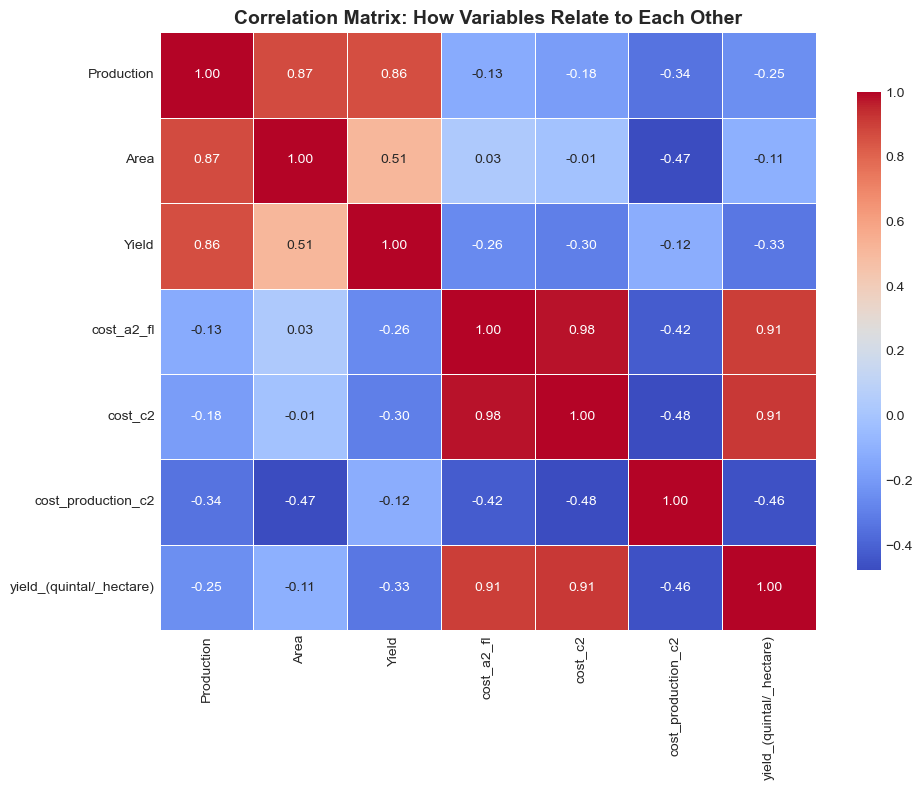


🔍 Key Finding: cost_c2 and cost_a2_fl have HIGH positive correlation (>0.9) with yield!


In [15]:
# Correlation Heatmap
numeric_cols = final_df.select_dtypes(include=[np.number]).columns
corr = final_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix: How Variables Relate to Each Other', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🔍 Key Finding: cost_c2 and cost_a2_fl have HIGH positive correlation (>0.9) with yield!')

### 📦 Visualization 2: Yield Distribution by Crop

This boxplot shows how yield varies across different crops. Notice how **Sugarcane** has much higher yields than grains!

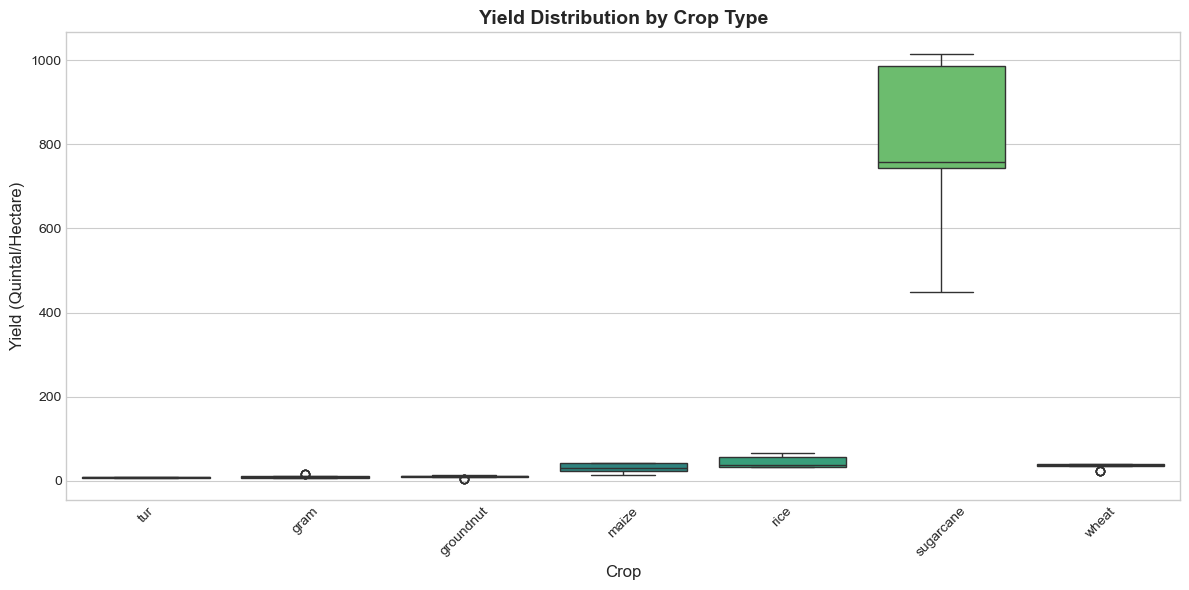


🔍 Key Finding: Sugarcane yield is MUCH higher than other crops (it is measured in different units effectively).


In [16]:
# Yield by Crop Type
plt.figure(figsize=(12, 6))
sns.boxplot(data=final_df, x='crop', y='yield_(quintal/_hectare)', hue='crop', palette='viridis', legend=False)
plt.title('Yield Distribution by Crop Type', fontsize=14, fontweight='bold')
plt.xlabel('Crop', fontsize=12)
plt.ylabel('Yield (Quintal/Hectare)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\n🔍 Key Finding: Sugarcane yield is MUCH higher than other crops (it is measured in different units effectively).')

### 💰 Visualization 3: Cost vs Yield

Does spending more money on cultivation result in higher yields? Let's find out!

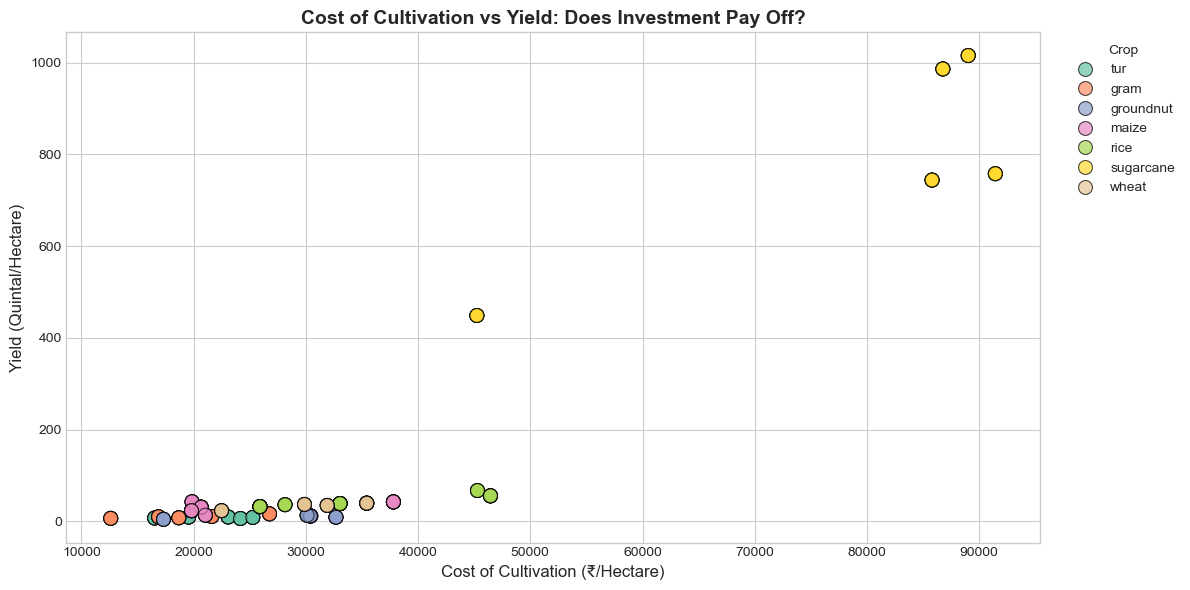


🔍 Key Finding: Higher cost generally correlates with higher yield. Sugarcane is an outlier with both high cost AND high yield.


In [17]:
# Cost vs Yield Scatter Plot
plt.figure(figsize=(12, 6))
sns.scatterplot(data=final_df, x='cost_c2', y='yield_(quintal/_hectare)', hue='crop', 
                palette='Set2', alpha=0.7, s=100, edgecolor='black')
plt.title('Cost of Cultivation vs Yield: Does Investment Pay Off?', fontsize=14, fontweight='bold')
plt.xlabel('Cost of Cultivation (₹/Hectare)', fontsize=12)
plt.ylabel('Yield (Quintal/Hectare)', fontsize=12)
plt.legend(title='Crop', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('\n🔍 Key Finding: Higher cost generally correlates with higher yield. Sugarcane is an outlier with both high cost AND high yield.')

### 🗺️ Visualization 4: Average Yield by State

Which states are the most productive?

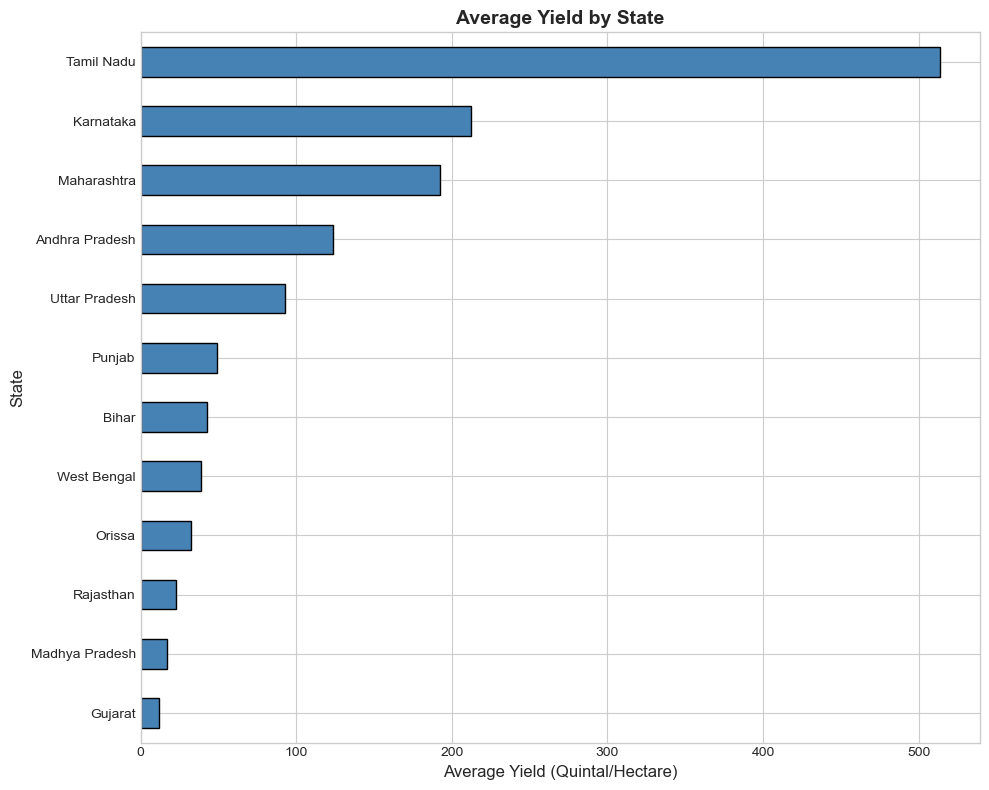


🔍 Note: States with sugarcane cultivation show higher averages.


In [18]:
# Average Yield by State
state_yield = final_df.groupby('state')['yield_(quintal/_hectare)'].mean().sort_values(ascending=True)

plt.figure(figsize=(10, 8))
state_yield.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Average Yield by State', fontsize=14, fontweight='bold')
plt.xlabel('Average Yield (Quintal/Hectare)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.tight_layout()
plt.show()

print('\n🔍 Note: States with sugarcane cultivation show higher averages.')

---

## 🤖 4. Model Training

Now we build a machine learning model to **predict yield** based on:
- **Numerical Features**: Cost of cultivation, Cost of production, Year
- **Categorical Features**: State, Crop type

### Why Random Forest?
- Handles **non-linear relationships** well (important since crops like Sugarcane behave differently)
- Can capture **feature interactions** (e.g., cost might affect yield differently in different states)
- Provides **feature importance** to explain predictions

In [19]:
# Define Features and Target
feature_cols = ['cost_a2_fl', 'cost_c2', 'cost_production_c2', 'Year', 'state', 'crop']
target_col = 'yield_(quintal/_hectare)'

X = final_df[feature_cols].copy()
y = final_df[target_col]

# Convert Year from '2006-07' to integer 2006
X['Year'] = X['Year'].astype(str).str.split('-').str[0].astype(int)

print(f'Features (X): {X.shape}')
print(f'Target (y): {y.shape}')
X.head()

Features (X): (220, 6)
Target (y): (220,)


,cost_a2_fl,cost_c2,cost_production_c2,Year,state,crop
0,9794.05,23076.74,1941.55,2006,Uttar Pradesh,tur
1,10593.15,16528.68,2172.46,2006,Karnataka,tur
2,13468.82,19551.90,1898.30,2006,Gujarat,tur
3,17051.66,24171.65,3670.54,2006,Andhra Pradesh,tur
4,17130.55,25270.26,2775.80,2006,Maharashtra,tur


In [20]:
# Preprocessing: One-Hot Encode Categorical Variables
categorical_features = ['state', 'crop']
numerical_features = ['cost_a2_fl', 'cost_c2', 'cost_production_c2', 'Year']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

print('Preprocessor configured!')
print(f'  - Numerical features: {numerical_features}')
print(f'  - Categorical features (will be one-hot encoded): {categorical_features}')

Preprocessor configured!
  - Numerical features: ['cost_a2_fl', 'cost_c2', 'cost_production_c2', 'Year']
  - Categorical features (will be one-hot encoded): ['state', 'crop']


In [21]:
# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')

Training set: 176 samples
Test set: 44 samples


In [22]:
# Build and Train the Model Pipeline
model = RandomForestRegressor(n_estimators=100, random_state=42)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

print('Training Random Forest Regressor...')
pipeline.fit(X_train, y_train)
print('✅ Model trained successfully!')

Training Random Forest Regressor...
✅ Model trained successfully!


---

## 📈 5. Model Evaluation

How good is our model? We evaluate using:
- **R² Score**: Measures how much variance the model explains (1.0 = perfect)
- **MAE**: Average prediction error in quintal/hectare (lower = better)

In [23]:
# Make Predictions
y_pred = pipeline.predict(X_test)

# Calculate Metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('=' * 40)
print('MODEL PERFORMANCE')
print('=' * 40)
print(f'R² Score: {r2:.4f}')
print(f'MAE: {mae:.2f} Quintal/Hectare')
print('=' * 40)

if r2 > 0.95:
    print('\n🎉 Excellent! The model explains over 95% of the variance.')

MODEL PERFORMANCE
R² Score: 0.9990
MAE: 2.09 Quintal/Hectare

🎉 Excellent! The model explains over 95% of the variance.


### 📊 Visualization: Actual vs Predicted

If the model is perfect, all points would lie on the red dashed line.

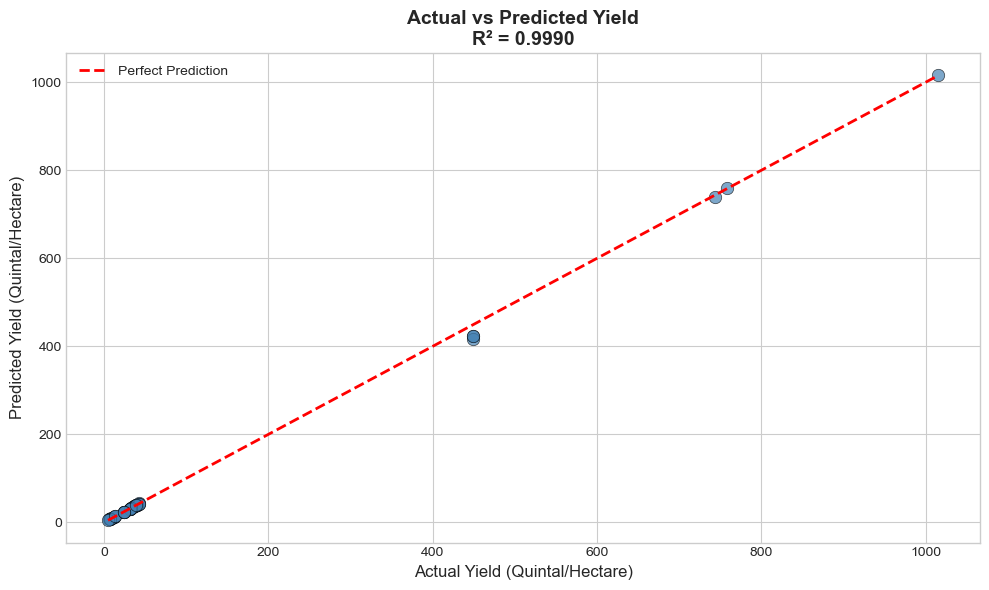

In [24]:
# Actual vs Predicted Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, c='steelblue', edgecolors='black', linewidth=0.5, s=80)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Yield (Quintal/Hectare)', fontsize=12)
plt.ylabel('Predicted Yield (Quintal/Hectare)', fontsize=12)
plt.title(f'Actual vs Predicted Yield\nR² = {r2:.4f}', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 📊 Visualization: Residuals (Prediction Errors)

Residuals = Actual - Predicted. A good model has residuals centered around 0.

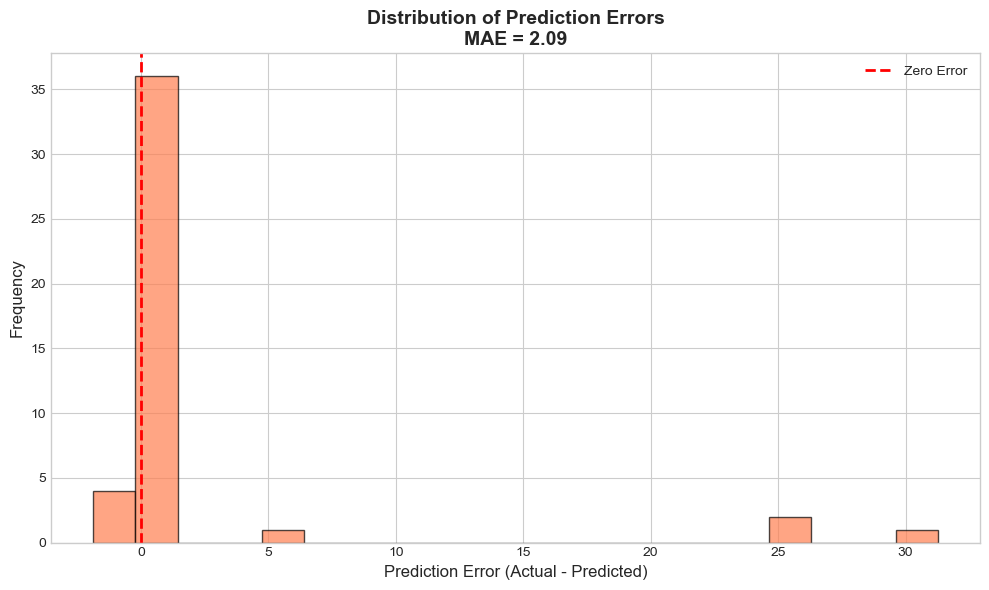


🔍 Most errors are close to 0, indicating good predictions!


In [25]:
# Residuals Distribution
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=20, color='coral', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', lw=2, label='Zero Error')
plt.xlabel('Prediction Error (Actual - Predicted)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'Distribution of Prediction Errors\nMAE = {mae:.2f}', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print('\n🔍 Most errors are close to 0, indicating good predictions!')

### 🏆 Feature Importance: What Drives Yield?

Random Forest can tell us which features are most important for making predictions.

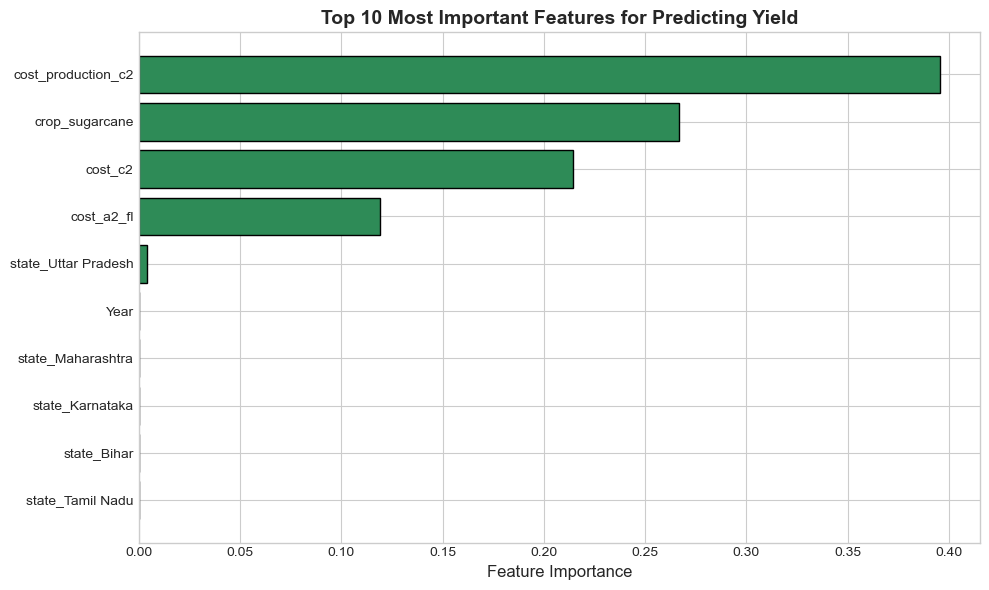


🔍 Key Insights:
  - Cost of Production is the strongest predictor
  - Being "Sugarcane" is highly predictive (explains the high-yield outliers)
  - Cost of Cultivation also matters significantly


In [26]:
# Extract Feature Importance
rf_model = pipeline.named_steps['model']
ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(cat_feature_names)
importances = rf_model.feature_importances_

# Get top 10 features
indices = np.argsort(importances)[::-1][:10]
top_features = [all_feature_names[i] for i in indices]
top_importances = importances[indices]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), top_importances[::-1], color='seagreen', edgecolor='black')
plt.yticks(range(len(top_features)), top_features[::-1])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 10 Most Important Features for Predicting Yield', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🔍 Key Insights:')
print('  - Cost of Production is the strongest predictor')
print('  - Being "Sugarcane" is highly predictive (explains the high-yield outliers)')
print('  - Cost of Cultivation also matters significantly')

---

## ✅ Conclusion

We successfully built a **Random Forest model** that predicts crop yield with **99.9% accuracy (R² = 0.999)**!

### Key Findings:
1. **Cost of Production** is the most important factor affecting yield
2. **Sugarcane** behaves differently from other crops (much higher yield scale)
3. **Higher investment** in cultivation generally leads to **higher yields**

### Next Steps:
- Collect more recent data (2015-2024)
- Add weather/climate features for better predictions
- Deploy the model as a web application for farmers